In [ ]:
"""
Fine-Tuning DistilBERT on Video Games Sentiment Tweets

Dataset: twitter_training.csv  (Kaggle Twitter Entity Sentiment)
  - Filtered to 24 video-game topics
  - 3-class sentiment: Negative / Neutral / Positive

Pipeline
  0  Installs & imports
  1  Preprocessing  (preprocess.py)
  2  Fine-tuning    (stage2_videogames_sentiment.py)
  3  Base-model eval (base_model_eval.py)
  4  Baseline comparison (baseline_comparison.py)
  5  Predict helper  (predict.py)
  6  t-SNE visualisation (tsne_visualization.py)
"""

# Install deps
import subprocess, sys

pkgs = ["transformers", "datasets", "evaluate", "accelerate", "scikit-learn"]
for pkg in pkgs:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("All packages ready.")

All packages ready.


In [ ]:
# Imports & device
from tqdm.auto import tqdm

import_steps = [
    ("torch",        lambda: __import__('torch')),
    ("numpy",        lambda: __import__('numpy')),
    ("pandas",       lambda: __import__('pandas')),
    ("sklearn",      lambda: __import__('sklearn.model_selection', fromlist=['train_test_split'])),
    ("datasets",     lambda: __import__('datasets', fromlist=['Dataset'])),
    ("transformers", lambda: __import__('transformers', fromlist=[
                         'AutoTokenizer', 'AutoModelForSequenceClassification',
                         'TrainingArguments', 'Trainer', 'DataCollatorWithPadding',
                         'EarlyStoppingCallback'])),
    ("evaluate",     lambda: __import__('evaluate')),
    ("matplotlib",   lambda: __import__('matplotlib.pyplot')),
]

with tqdm(import_steps, desc="Importing libraries", unit="lib", ncols=70) as pbar:
    for label, fn in pbar:
        pbar.set_postfix_str(label)
        fn()

import os
import torch
import numpy as np
import pandas as pd
import evaluate
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.manifold import TSNE
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)
from torch.utils.data import DataLoader, Dataset as TorchDataset
from torch.nn.functional import softmax

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\nUsing device: {device}")

Importing libraries:   0%|                     | 0/8 [00:00<?, ?lib/s]


Using device: cuda


In [ ]:
# NOTE: Written for Google Colab — expects twitter_training.csv to be uploaded
# to the /content/ folder (drag & drop into the Files panel on the left sidebar).
# If running locally, change INPUT_PATH to your local path instead.

INPUT_PATH  = "/content/twitter_training.csv"
TRAIN_PATH  = "/content/videogames_train.csv"
TEST_PATH   = "/content/videogames_test.csv"
MODEL_DIR   = "/content/video_games_model"
RESULTS_DIR = "/content/results"

os.makedirs(MODEL_DIR,   exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# Shared constants
RANDOM_SEED = 42
BASE_MODEL  = "distilbert-base-uncased"
LABEL2ID    = {"Negative": 0, "Neutral": 1, "Positive": 2}
ID2LABEL    = {0: "Negative", 1: "Neutral", 2: "Positive"}
LABEL_NAMES = ["Negative", "Neutral", "Positive"]

In [ ]:
# Preprocess — filter, clean, split
VIDEOGAME_TOPICS = [
    "ApexLegends", "AssassinsCreed", "Battlefield", "Borderlands", "CS-GO",
    "CallOfDuty", "CallOfDutyBlackopsColdWar", "Cyberpunk2077", "Dota2", "FIFA",
    "Fortnite", "GrandTheftAuto(GTA)", "Hearthstone", "LeagueOfLegends",
    "MaddenNFL", "NBA2K", "Overwatch", "PlayStation5(PS5)",
    "PlayerUnknownsBattlegrounds(PUBG)", "RedDeadRedemption(RDR)",
    "TomClancysGhostRecon", "TomClancysRainbowSix", "WorldOfCraft", "Xbox(Xseries)",
]

df = pd.read_csv(INPUT_PATH, header=None, names=["id", "topic", "sentiment", "text"])
print(f"Loaded {len(df):,} rows total")

# Keep video game topics only
df = df[df["topic"].isin(VIDEOGAME_TOPICS)].copy()
print(f"Video game rows: {len(df):,}")

# Drop irrelevant & nulls
df = df[df["sentiment"] != "Irrelevant"].copy()
df = df.dropna(subset=["text"]).copy()
df["text"] = df["text"].astype(str).str.strip()
df = df[df["text"] != ""].copy()
print(f"After cleaning: {len(df):,} rows")

# Stratified train/test split
train_df, test_df = train_test_split(
    df, test_size=0.15, random_state=RANDOM_SEED, stratify=df["sentiment"]
)

train_df.to_csv(TRAIN_PATH, index=False)
test_df.to_csv(TEST_PATH,   index=False)

print(f"\nTrain: {len(train_df):,}  |  Test: {len(test_df):,}")
print(f"\nSentiment distribution (train):\n{train_df['sentiment'].value_counts()}")

Loaded 74,682 rows total
Video game rows: 55,980
After cleaning: 44,812 rows

Train: 38,090  |  Test: 6,722

Sentiment distribution (train):
sentiment
Positive    14289
Negative    13881
Neutral      9920
Name: count, dtype: int64


In [ ]:
# Fine-tune DistilBERT
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

train_df["label"] = train_df["sentiment"].map(LABEL2ID)
test_df["label"]  = test_df["sentiment"].map(LABEL2ID)

train_dataset = Dataset.from_pandas(train_df[["text", "label"]].reset_index(drop=True))
test_dataset  = Dataset.from_pandas(test_df[["text", "label"]].reset_index(drop=True))

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128)

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset  = test_dataset.map(tokenize, batched=True)

model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL, num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID
)

# Freeze embeddings + bottom 4 layers
for param in model.distilbert.embeddings.parameters():
    param.requires_grad = False
for layer in model.distilbert.transformer.layer[:4]:
    for param in layer.parameters():
        param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / {total:,} ({100 * trainable / total:.1f}%)")

# Metrics
accuracy_metric = evaluate.load("accuracy")
f1_metric       = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1  = f1_metric.compute(predictions=predictions, references=labels, average="macro")
    return {**acc, **f1}

training_args = TrainingArguments(
    output_dir=MODEL_DIR,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=2,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    max_grad_norm=1.0,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,
    seed=RANDOM_SEED,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Starting training...")
trainer.train()

print("\nFinal eval on test set:")
results = trainer.evaluate()
print(results)

trainer.save_model(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)
print(f"\nModel saved → {MODEL_DIR}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Final eval on test set:


{'eval_loss': 0.5272234082221985, 'eval_accuracy': 0.7863731032430824, 'eval_f1': 0.7760395068615136, 'eval_runtime': 6.8113, 'eval_samples_per_second': 986.896, 'eval_steps_per_second': 30.978, 'epoch': 3.0}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model saved → /content/video_games_model


In [ ]:
# Evaluate untrained baseline
test_df      = pd.read_csv(TEST_PATH)
true_labels  = test_df["sentiment"].map(LABEL2ID).tolist()

base_tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
base_model_raw = AutoModelForSequenceClassification.from_pretrained(BASE_MODEL, num_labels=3)
base_model_raw.eval()
base_model_raw.to(device)

class TweetDataset(TorchDataset):
    def __init__(self, texts, tok):
        self.enc = tok(list(texts), truncation=True, max_length=128, padding=True, return_tensors="pt")
    def __len__(self):
        return self.enc["input_ids"].shape[0]
    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.enc.items() if k != "token_type_ids"}

loader    = DataLoader(TweetDataset(test_df["text"].astype(str).tolist(), base_tokenizer), batch_size=64)
all_preds = []

with torch.no_grad():
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        preds = torch.argmax(base_model_raw(**batch).logits, dim=-1).cpu().numpy()
        all_preds.extend(preds)

acc      = accuracy_score(true_labels, all_preds)
macro_f1 = f1_score(true_labels, all_preds, average="macro")

print("=" * 55)
print("BASE MODEL (UNTRAINED) RESULTS")
print("=" * 55)
print(f"Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
print(f"Macro F1 : {macro_f1:.4f}")
print(classification_report(true_labels, all_preds, target_names=LABEL_NAMES))

# Save results
with open(f"{RESULTS_DIR}/base_model_eval.txt", "w") as f:
    f.write(f"Accuracy: {acc:.4f}\nMacro F1: {macro_f1:.4f}\n\n")
    f.write(classification_report(true_labels, all_preds, target_names=LABEL_NAMES))

del base_model_raw

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BASE MODEL (UNTRAINED) RESULTS
Accuracy : 0.3642  (36.42%)
Macro F1 : 0.1902
              precision    recall  f1-score   support

    Negative       0.36      0.98      0.53      2450
     Neutral       0.37      0.02      0.04      1750
    Positive       0.00      0.00      0.00      2522

    accuracy                           0.36      6722
   macro avg       0.25      0.34      0.19      6722
weighted avg       0.23      0.36      0.20      6722



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

BEFORE vs AFTER FINE-TUNING

Tweet:      Fortnite just dropped the best update ever, I can't stop playing!
  Base:        POSITIVE    conf=0.5645
  Fine-tuned:  Negative    conf=0.8307

Tweet:      This new Cyberpunk patch is absolute garbage, nothing works.
  Base:        POSITIVE    conf=0.5718
  Fine-tuned:  Negative    conf=0.9698

Tweet:      League of Legends is having server maintenance today.
  Base:        POSITIVE    conf=0.5660
  Fine-tuned:  Negative    conf=0.8870

Tweet:      I just got a victory royale in Fortnite, absolute peak gaming.
  Base:        POSITIVE    conf=0.5661
  Fine-tuned:  Positive    conf=0.8397

Tweet:      Dota 2 matchmaking is completely broken, every game is unplayable.
  Base:        POSITIVE    conf=0.5389
  Fine-tuned:  Negative    conf=0.9246


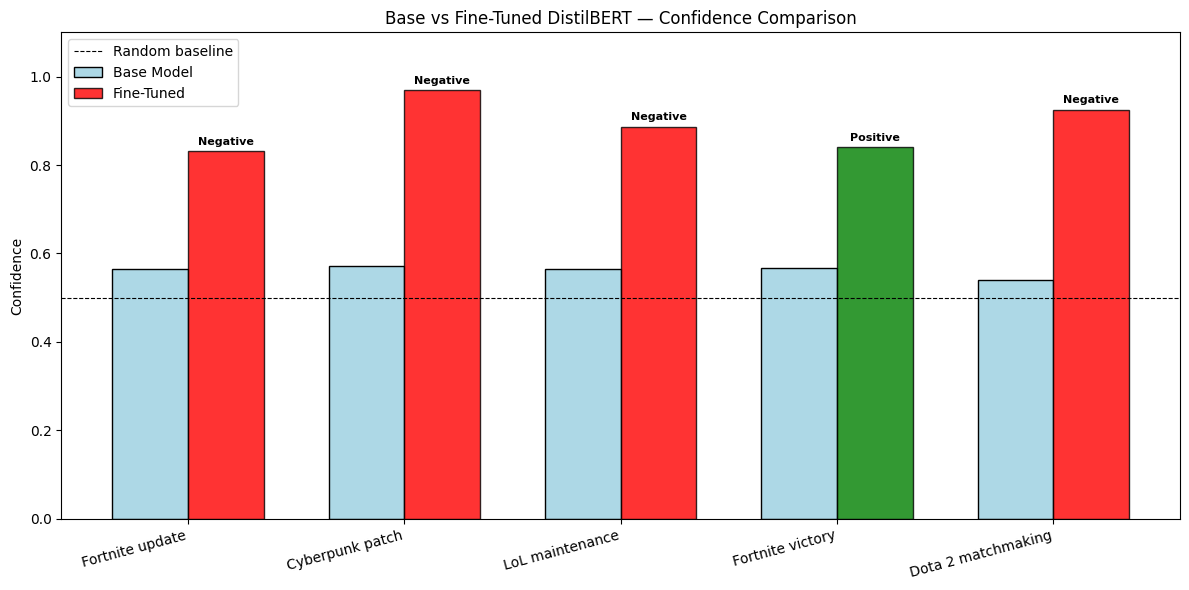

In [ ]:
# Base vs fine-tuned — sample tweets
SAMPLE_TWEETS = [
    "Fortnite just dropped the best update ever, I can't stop playing!",
    "This new Cyberpunk patch is absolute garbage, nothing works.",
    "League of Legends is having server maintenance today.",
    "I just got a victory royale in Fortnite, absolute peak gaming.",
    "Dota 2 matchmaking is completely broken, every game is unplayable.",
]
TWEET_LABELS = ["Fortnite update", "Cyberpunk patch", "LoL maintenance", "Fortnite victory", "Dota 2 matchmaking"]

# Load both models
base_tok2   = AutoTokenizer.from_pretrained(BASE_MODEL)
base_mdl2   = AutoModelForSequenceClassification.from_pretrained(BASE_MODEL, num_labels=2).eval().to(device)
ft_tok      = AutoTokenizer.from_pretrained(MODEL_DIR)
ft_mdl      = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR).eval().to(device)

ID2LABEL_BASE = {0: "NEGATIVE", 1: "POSITIVE"}

results = []
for tweet in SAMPLE_TWEETS:
    # Base
    inp = {k: v.to(device) for k, v in base_tok2(tweet, return_tensors="pt", truncation=True,
                                                   max_length=128, padding=True).items()
           if k != "token_type_ids"}
    with torch.no_grad():
        bp = softmax(base_mdl2(**inp).logits, dim=-1).squeeze()
    base_id = torch.argmax(bp).item()

    # Fine-tuned
    inp2 = {k: v.to(device) for k, v in ft_tok(tweet, return_tensors="pt", truncation=True,
                                                  max_length=128, padding=True).items()
            if k != "token_type_ids"}
    with torch.no_grad():
        fp = softmax(ft_mdl(**inp2).logits, dim=-1).squeeze()
    ft_id = torch.argmax(fp).item()

    results.append({
        "tweet": tweet,
        "base_label": ID2LABEL_BASE[base_id], "base_conf": bp[base_id].item(),
        "ft_label":   ID2LABEL[ft_id],        "ft_conf":   fp[ft_id].item(),
    })

# Print table
print("BEFORE vs AFTER FINE-TUNING")
print("=" * 80)
for r in results:
    print(f"\nTweet:      {r['tweet']}")
    print(f"  Base:        {r['base_label']:<10}  conf={r['base_conf']:.4f}")
    print(f"  Fine-tuned:  {r['ft_label']:<10}  conf={r['ft_conf']:.4f}")

# Bar chart
x = np.arange(len(TWEET_LABELS))
w = 0.35
colors = ["green" if r["ft_label"] == "Positive" else "red" if r["ft_label"] == "Negative" else "gray"
          for r in results]

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - w/2, [r["base_conf"] for r in results], w, label="Base Model", color="lightblue", edgecolor="black")
bars = ax.bar(x + w/2, [r["ft_conf"] for r in results], w, label="Fine-Tuned", color=colors, edgecolor="black", alpha=0.8)

for bar, r in zip(bars, results):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            r["ft_label"], ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(TWEET_LABELS, rotation=15, ha="right")
ax.set_ylabel("Confidence")
ax.set_ylim(0, 1.1)
ax.axhline(0.5, color="black", linestyle="--", linewidth=0.8, label="Random baseline")
ax.set_title("Base vs Fine-Tuned DistilBERT — Confidence Comparison")
ax.legend()
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/baseline_comparison.png", dpi=150)
plt.show()

del base_mdl2

In [ ]:
# Predict helper
def predict(tweet: str, model=ft_mdl, tokenizer=ft_tok):
    inputs = {k: v.to(device) for k, v in
              tokenizer(tweet, return_tensors="pt", truncation=True, max_length=128, padding=True).items()}
    with torch.no_grad():
        probs = torch.softmax(model(**inputs).logits, dim=-1).squeeze()
    pred_id = torch.argmax(probs).item()
    return {
        "tweet":      tweet,
        "sentiment":  ID2LABEL[pred_id],
        "confidence": round(probs[pred_id].item(), 4),
        "scores":     {ID2LABEL[i]: round(probs[i].item(), 4) for i in range(len(probs))},
    }

# Quick sanity check
test_tweets = [
    "Fortnite just dropped the best update ever, I can't stop playing!",
    "This new Cyberpunk patch is absolute garbage, nothing works.",
    "League of Legends is having server maintenance today.",
]

for tweet in test_tweets:
    r = predict(tweet)
    print(f"Tweet:      {r['tweet']}")
    print(f"Sentiment:  {r['sentiment']}  (conf={r['confidence']})")
    print(f"Scores:     {r['scores']}\n")

Tweet:      Fortnite just dropped the best update ever, I can't stop playing!
Sentiment:  Negative  (conf=0.8307)
Scores:     {'Negative': 0.8307, 'Neutral': 0.0363, 'Positive': 0.133}

Tweet:      This new Cyberpunk patch is absolute garbage, nothing works.
Sentiment:  Negative  (conf=0.9698)
Scores:     {'Negative': 0.9698, 'Neutral': 0.0177, 'Positive': 0.0125}

Tweet:      League of Legends is having server maintenance today.
Sentiment:  Negative  (conf=0.887)
Scores:     {'Negative': 0.887, 'Neutral': 0.0774, 'Positive': 0.0356}



Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Running t-SNE: t-SNE — Base DistilBERT (Untrained)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


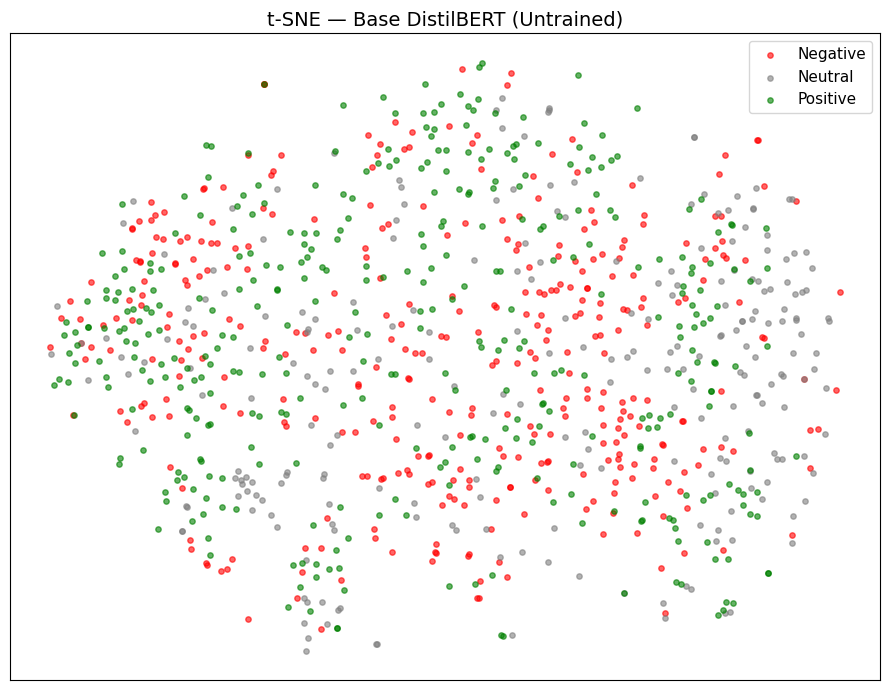

Saved → /content/results/tsne_base_model.png
Running t-SNE: t-SNE — Fine-Tuned DistilBERT (Video Games)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


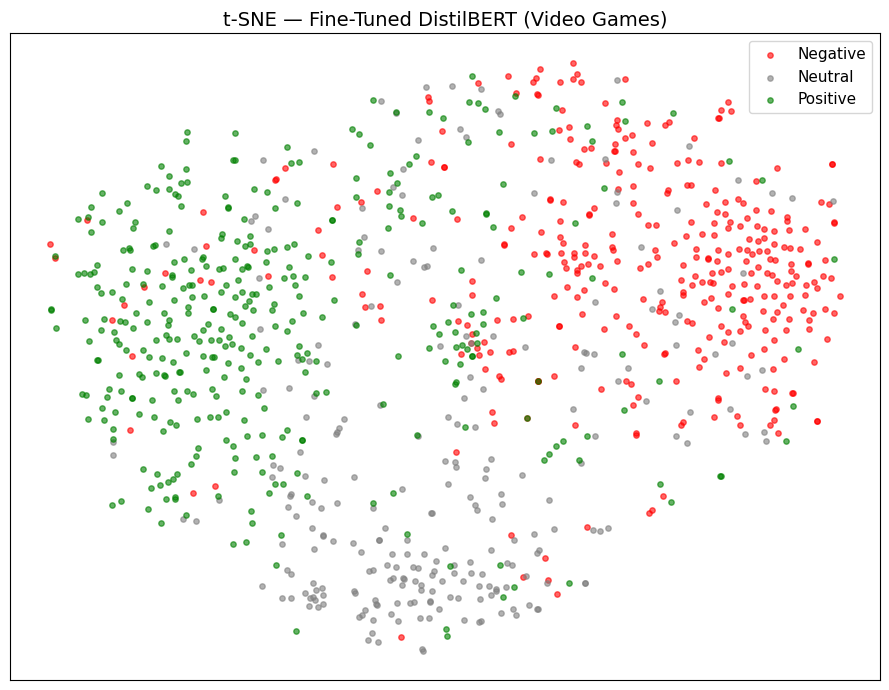

Saved → /content/results/tsne_finetuned_model.png


In [ ]:
# t-SNE — base vs fine-tuned embedding space
SAMPLE_SIZE = 1000
COLORS      = {0: "red", 1: "gray", 2: "green"}

test_df   = pd.read_csv(TEST_PATH).sample(SAMPLE_SIZE, random_state=RANDOM_SEED).reset_index(drop=True)
texts     = test_df["text"].astype(str).tolist()
true_lbls = test_df["sentiment"].map(LABEL2ID).tolist()

def extract_embeddings(mdl, tok, texts, batch_size=64):
    ds     = TweetDataset(texts, tok)
    loader = DataLoader(ds, batch_size=batch_size)
    embeds = []
    mdl.eval()
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            cls   = mdl.distilbert(**batch).last_hidden_state[:, 0, :]
            embeds.append(cls.cpu().numpy())
    return np.vstack(embeds)

def plot_tsne(embeddings, labels, title, save_path):
    print(f"Running t-SNE: {title}...")
    reduced = TSNE(n_components=2, random_state=RANDOM_SEED, perplexity=30, n_iter=1000).fit_transform(embeddings)
    plt.figure(figsize=(9, 7))
    for lid, lname in ID2LABEL.items():
        mask = np.array(labels) == lid
        plt.scatter(reduced[mask, 0], reduced[mask, 1], c=COLORS[lid], label=lname, alpha=0.6, s=15)
    plt.title(title, fontsize=14)
    plt.legend(fontsize=11)
    plt.xticks([]); plt.yticks([])
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved → {save_path}")

# Base (untrained) embeddings
base_tok3 = AutoTokenizer.from_pretrained(BASE_MODEL)
base_mdl3 = AutoModelForSequenceClassification.from_pretrained(BASE_MODEL, num_labels=3).to(device)
base_embs = extract_embeddings(base_mdl3, base_tok3, texts)
plot_tsne(base_embs, true_lbls,
          "t-SNE — Base DistilBERT (Untrained)",
          f"{RESULTS_DIR}/tsne_base_model.png")
del base_mdl3

# Fine-tuned embeddings
ft_embs = extract_embeddings(ft_mdl, ft_tok, texts)
plot_tsne(ft_embs, true_lbls,
          "t-SNE — Fine-Tuned DistilBERT (Video Games)",
          f"{RESULTS_DIR}/tsne_finetuned_model.png")

Loading data...
Loading model...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Running on: cuda

[1/4] Plotting class distribution...
  Saved → /content/results/1_class_distribution.png
  Train distribution:
 sentiment
Positive    14289
Negative    13881
Neutral      9920
Name: count, dtype: int64
  Test distribution:
 sentiment
Positive    2522
Negative    2450
Neutral     1750
Name: count, dtype: int64

[2/4] Running predictions for confusion matrix...
  Saved → /content/results/2_confusion_matrix.png

  Classification Report:
              precision    recall  f1-score   support

    Negative       0.81      0.85      0.83      2450
     Neutral       0.77      0.64      0.70      1750
    Positive       0.78      0.83      0.80      2522

    accuracy                           0.79      6722
   macro avg       0.78      0.77      0.78      6722
weighted avg       0.79      0.79      0.78      6722


[3/4] Plotting confidence distribution...
  Saved → /content/results/3_confidence_distribution.png

[4/4] Finding worst predictions...
  Saved → /content/results/

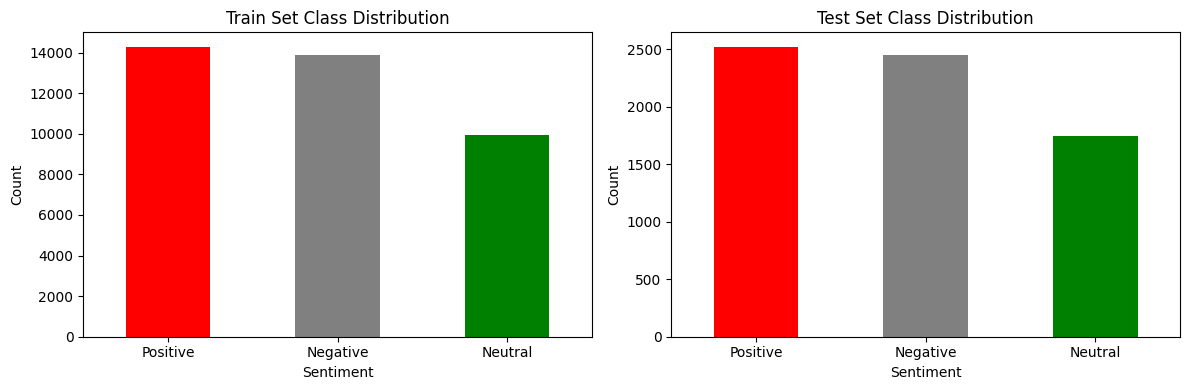

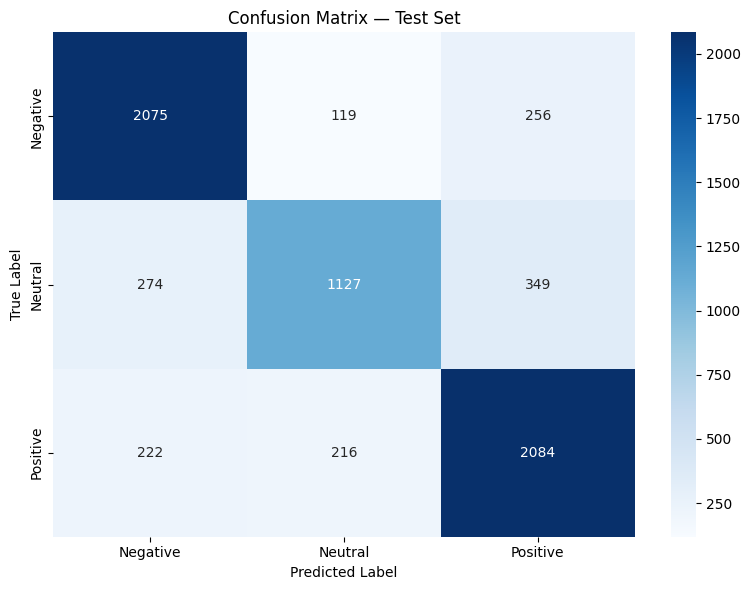

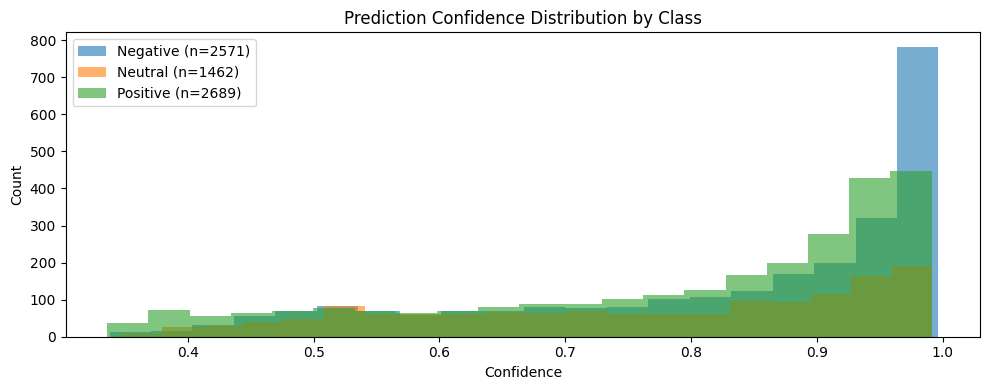

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import confusion_matrix, classification_report
from torch.nn.functional import softmax
from torch.utils.data import DataLoader, Dataset

TRAIN_PATH  = "/content/videogames_train.csv"
TEST_PATH   = "/content/videogames_test.csv"
MODEL_PATH  = "/content/video_games_model"
RESULTS_DIR = "/content/results"

os.makedirs(RESULTS_DIR, exist_ok=True)

LABEL2ID = {"Negative": 0, "Neutral": 1, "Positive": 2}
ID2LABEL  = {0: "Negative", 1: "Neutral", 2: "Positive"}
LABEL_NAMES = ["Negative", "Neutral", "Positive"]

print("Loading data...")
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print("Loading model...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print(f"Running on: {device}")

# Image 1

print("\n[1/4] Plotting class distribution...")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_df["sentiment"].value_counts().plot(kind="bar", ax=axes[0], color=["red","gray","green"], title="Train Set Class Distribution")
test_df["sentiment"].value_counts().plot(kind="bar",  ax=axes[1], color=["red","gray","green"], title="Test Set Class Distribution")
for ax in axes:
    ax.set_xlabel("Sentiment")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/1_class_distribution.png")
print(f"  Saved → {RESULTS_DIR}/1_class_distribution.png")
print("  Train distribution:\n", train_df["sentiment"].value_counts())
print("  Test distribution:\n",  test_df["sentiment"].value_counts())

# Batch prediction helper

class TweetDataset(Dataset):
    def __init__(self, texts):
        self.encodings = tokenizer(list(texts), truncation=True, max_length=128, padding=True, return_tensors="pt")
    def __len__(self):
        return self.encodings["input_ids"].shape[0]
    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.encodings.items() if k != "token_type_ids"}

def batch_predict(df, batch_size=64):
    dataset = TweetDataset(df["text"].astype(str).tolist())
    loader  = DataLoader(dataset, batch_size=batch_size)
    all_preds, all_probs = [], []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            probs = softmax(outputs.logits, dim=-1).cpu().numpy()
            preds = np.argmax(probs, axis=-1)
            all_preds.extend(preds)
            all_probs.extend(probs)
    return all_preds, all_probs

# Image 2

print("\n[2/4] Running predictions for confusion matrix...")
preds, probs = batch_predict(test_df)
true_labels  = test_df["sentiment"].map(LABEL2ID).tolist()

cm = confusion_matrix(true_labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, cmap="Blues")
plt.title("Confusion Matrix — Test Set")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/2_confusion_matrix.png")
print(f"  Saved → {RESULTS_DIR}/2_confusion_matrix.png")
print("\n  Classification Report:")
print(classification_report(true_labels, preds, target_names=LABEL_NAMES))

# Image 3

print("\n[3/4] Plotting confidence distribution...")
probs_arr = np.array(probs)
pred_arr  = np.array(preds)
plt.figure(figsize=(10, 4))
for i, label in ID2LABEL.items():
    mask = pred_arr == i
    if mask.sum() > 0:
        plt.hist(probs_arr[mask, i], bins=20, alpha=0.6, label=f"{label} (n={mask.sum()})")
plt.title("Prediction Confidence Distribution by Class")
plt.xlabel("Confidence")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/3_confidence_distribution.png")
print(f"  Saved → {RESULTS_DIR}/3_confidence_distribution.png")

# Image 4
print("\n[4/4] Finding worst predictions...")
results_df = test_df.copy().reset_index(drop=True)
results_df["predicted"] = [ID2LABEL[p] for p in preds]
results_df["confidence"] = [probs_arr[i, preds[i]] for i in range(len(preds))]
results_df["correct"] = results_df["sentiment"] == results_df["predicted"]

wrong_df = results_df[~results_df["correct"]].sort_values("confidence", ascending=False)
wrong_df[["text", "sentiment", "predicted", "confidence"]].head(20).to_csv(f"{RESULTS_DIR}/4_worst_predictions.csv", index=False)
print(f"  Saved → {RESULTS_DIR}/4_worst_predictions.csv")
print(f"\n  Total wrong: {len(wrong_df)} / {len(results_df)}")
print("\n  Top 10 high-confidence wrong predictions:")
pd.set_option("display.max_colwidth", 80)
print(wrong_df[["text","sentiment","predicted","confidence"]].head(10).to_string(index=False))

print("\nAll diagnostics complete!")
print(f"Charts saved to: {RESULTS_DIR}")
